In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

# Upload your CSV in Google Colab first:
# from google.colab import files
# uploaded = files.upload()

FILE_PATH = "/content/Banglore_traffic_Dataset.csv"

df_original = pd.read_csv(FILE_PATH)

print("Original dataset shape:", df_original.shape)
print("\nColumn names:")
print(df_original.columns.tolist())

display(df_original.head())

Original dataset shape: (8936, 16)

Column names:
['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact', 'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count', 'Weather Conditions', 'Roadwork and Construction Activity']


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [3]:
# ============================================================
# 3. BASIC DATASET INSPECTION
# ============================================================

print("Original number of rows:", len(df_original))
print("Original number of columns:", df_original.shape[1])

print("\nData types:")
display(df_original.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df_original.info()

print("\nDescriptive statistics:")
display(df_original.describe(include="all").T)

Original number of rows: 8936
Original number of columns: 16

Data types:


,Data Type
Date,object
Area Name,object
Road/Intersection Name,object
Traffic Volume,int64
Average Speed,float64
Travel Time Index,float64
Congestion Level,float64
Road Capacity Utilization,float64
Incident Reports,int64
Environmental Impact,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compli

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8936,952,2023-01-24,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Name,8936,8,Indiranagar,1720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road/Intersection Name,8936,16,100 Feet Road,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic Volume,8936.0,NaN,NaN,NaN,29236.04812,13001.808801,4233.0,19413.0,27600.0,38058.5,72039.0
Average Speed,8936.0,NaN,NaN,NaN,39.447427,10.707244,20.0,31.775825,39.199368,46.644517,89.790843
Travel Time Index,8936.0,NaN,NaN,NaN,1.375554,0.165319,1.000039,1.242459,1.5,1.5,1.5
Congestion Level,8936.0,NaN,NaN,NaN,80.818041,23.533182,5.160279,64.292905,92.389018,100.0,100.0
Road Capacity Utilization,8936.0,NaN,NaN,NaN,92.029215,16.583341,18.739771,97.35499,100.0,100.0,100.0
Incident Reports,8936.0,NaN,NaN,NaN,1.570389,1.420047,0.0,0.0,1.0,2.0,10.0
Environmental Impact,8936.0,NaN,NaN,NaN,108.472096,26.003618,58.466,88.826,105.2,126.117,194.078


In [4]:
# ============================================================
# 4. MISSING VALUES AND DUPLICATES
# ============================================================

missing = df_original.isnull().sum()
missing_percent = (missing / len(df_original)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})

print("Missing-value analysis:")
display(missing_table)

duplicate_count = df_original.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Missing-value analysis:


,Missing Count,Missing Percentage
Date,0,0.0
Area Name,0,0.0
Road/Intersection Name,0,0.0
Traffic Volume,0,0.0
Average Speed,0,0.0
Travel Time Index,0,0.0
Congestion Level,0,0.0
Road Capacity Utilization,0,0.0
Incident Reports,0,0.0
Environmental Impact,0,0.0


Number of duplicate rows: 0


In [5]:
# ============================================================
# 5. CHECK FOR ID / IRRELEVANT COLUMNS
# ============================================================

unique_table = pd.DataFrame({
    "Column": df_original.columns,
    "Unique Values": [df_original[c].nunique() for c in df_original.columns],
    "Data Type": [df_original[c].dtype for c in df_original.columns]
})

display(unique_table.sort_values("Unique Values"))

# Identify likely ID columns
possible_id_columns = []

for col in df_original.columns:
    col_lower = col.lower()

    if (
        "id" in col_lower
        or "index" in col_lower
        or "unnamed" in col_lower
    ):
        possible_id_columns.append(col)

print("Possible ID/index columns:", possible_id_columns)

,Column,Unique Values,Data Type
15,Roadwork and Construction Activity,2,object
14,Weather Conditions,5,object
1,Area Name,8,object
8,Incident Reports,11,int64
2,Road/Intersection Name,16,object
13,Pedestrian and Cyclist Count,148,int64
0,Date,952,object
7,Road Capacity Utilization,2352,float64
5,Travel Time Index,3711,float64
6,Congestion Level,5053,float64


Possible ID/index columns: ['Travel Time Index', 'Incident Reports']


In [6]:
# ============================================================
# 6. TARGET VARIABLE ANALYSIS
# ============================================================

TARGET = "Traffic Volume"

print("Target:", TARGET)
print("\nTarget data type:", df_original[TARGET].dtype)

print("\nTarget statistics:")
display(df_original[TARGET].describe())

print("\nTarget skewness:", df_original[TARGET].skew())
print("Target kurtosis:", df_original[TARGET].kurtosis())

Target: Traffic Volume

Target data type: int64

Target statistics:


,Traffic Volume
count,8936.000000
mean,29236.048120
std,13001.808801
min,4233.000000
25%,19413.000000
50%,27600.000000
75%,38058.500000
max,72039.000000



Target skewness: 0.4595351917895375
Target kurtosis: -0.3017564609103842


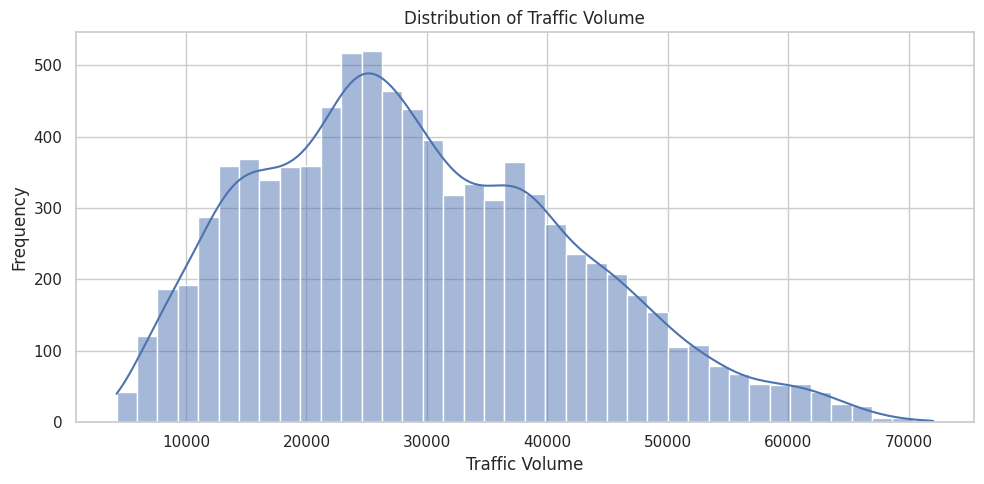

In [7]:
# ============================================================
# 7. TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df_original[TARGET],
    kde=True,
    bins=40
)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 8. OUTLIER DETECTION USING IQR
# ============================================================

numeric_columns = df_original.select_dtypes(
    include=np.number
).columns

outlier_summary = []

for col in numeric_columns:

    Q1 = df_original[col].quantile(0.25)
    Q3 = df_original[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_original[col] < lower_bound) |
        (df_original[col] > upper_bound)
    )

    outlier_summary.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers.sum(),
        "Outlier %": outliers.mean() * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.sort_values(
        "Outlier Count",
        ascending=False
    )
)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
4,Road Capacity Utilization,97.354990,100.000000,2.645010,93.387476,103.967514,2078,23.254252
10,Pedestrian and Cyclist Count,94.000000,111.000000,17.000000,68.500000,136.500000,1316,14.726947
5,Incident Reports,0.000000,2.000000,2.000000,-3.000000,5.000000,100,1.119069
1,Average Speed,31.775825,46.644517,14.868691,9.472789,68.947553,33,0.369293
0,Traffic Volume,19413.000000,38058.500000,18645.500000,-8555.250000,66026.750000,24,0.268577
6,Environmental Impact,88.826000,126.117000,37.291000,32.889500,182.053500,24,0.268577
3,Congestion Level,64.292905,100.000000,35.707095,10.732263,153.560642,3,0.033572
2,Travel Time Index,1.242459,1.500000,0.257541,0.856148,1.886311,0,0.000000
7,Public Transport Usage,27.341191,62.426485,35.085294,-25.286751,115.054426,0,0.000000
8,Traffic Signal Compliance,69.828270,89.957358,20.129088,39.634638,120.150990,0,0.000000


In [9]:
# ============================================================
# 9. DATE FEATURE ENGINEERING
# ============================================================

df = df_original.copy()

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek
df["Is_Weekend"] = (
    df["Day_of_Week"] >= 5
).astype(int)

print("Date range:")
print(df["Date"].min(), "to", df["Date"].max())

display(
    df[
        [
            "Date",
            "Year",
            "Month",
            "Day",
            "Day_of_Week",
            "Is_Weekend"
        ]
    ].head()
)

Date range:
2022-01-01 00:00:00 to 2024-08-09 00:00:00


,Date,Year,Month,Day,Day_of_Week,Is_Weekend
0,2022-01-01,2022,1,1,5,1
1,2022-01-01,2022,1,1,5,1
2,2022-01-01,2022,1,1,5,1
3,2022-01-01,2022,1,1,5,1
4,2022-01-01,2022,1,1,5,1


In [10]:
# ============================================================
# 10. REPRESENTATIVE RANDOM SAMPLE
# ============================================================

ORIGINAL_SIZE = len(df)

SAMPLE_SIZE = min(3000, ORIGINAL_SIZE)

if ORIGINAL_SIZE > 3000:

    df_sample = df.sample(
        n=3000,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    sampling_method = (
        "Simple random sampling without replacement "
        "using random_state=42"
    )

else:

    df_sample = df.copy().reset_index(drop=True)

    sampling_method = "Full dataset used because size <= 3000"

print("Original dataset size:", ORIGINAL_SIZE)
print("Sample size:", len(df_sample))
print("Sampling method:", sampling_method)

display(df_sample.head())

Original dataset size: 8936
Sample size: 3000
Sampling method: Simple random sampling without replacement using random_state=42


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,...,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,Year,Month,Day,Day_of_Week,Is_Weekend
0,2022-03-01,Indiranagar,CMH Road,47746,39.827901,1.500000,100.000000,100.0000,2,145.492,...,81.279533,90.451728,109,Fog,No,2022,3,1,1,0
1,2023-11-05,Koramangala,Sony World Junction,43420,27.078493,1.500000,100.000000,100.0000,4,136.840,...,78.758495,97.381480,95,Overcast,No,2023,11,5,6,1
2,2022-05-23,Whitefield,Marathahalli Bridge,22824,36.749881,1.025819,79.106799,100.0000,6,95.648,...,67.282704,52.811246,122,Windy,No,2022,5,23,0,0
3,2024-01-05,Yeshwanthpur,Tumkur Road,22899,63.823607,1.302248,73.844329,100.0000,3,95.798,...,82.320364,53.928973,116,Fog,No,2024,1,5,4,0
4,2023-05-31,Whitefield,Marathahalli Bridge,17274,28.045132,1.358012,59.958537,87.5728,1,84.548,...,66.484488,99.231643,95,Clear,No,2023,5,31,2,0


In [11]:
# ============================================================
# 11. DEFINE TARGET AND REMOVE LEAKAGE
# ============================================================

TARGET = "Traffic Volume"

# Environmental Impact has perfect correlation (1.00)
# with Traffic Volume in this dataset.
# It is therefore excluded to avoid potential target leakage.

LEAKAGE_COLUMNS = [
    "Environmental Impact"
]

df_model = df_sample.drop(
    columns=LEAKAGE_COLUMNS,
    errors="ignore"
).copy()

print("Removed columns:")
print(LEAKAGE_COLUMNS)

print("\nRemaining columns:")
print(df_model.columns.tolist())

Removed columns:
['Environmental Impact']

Remaining columns:
['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count', 'Weather Conditions', 'Roadwork and Construction Activity', 'Year', 'Month', 'Day', 'Day_of_Week', 'Is_Weekend']


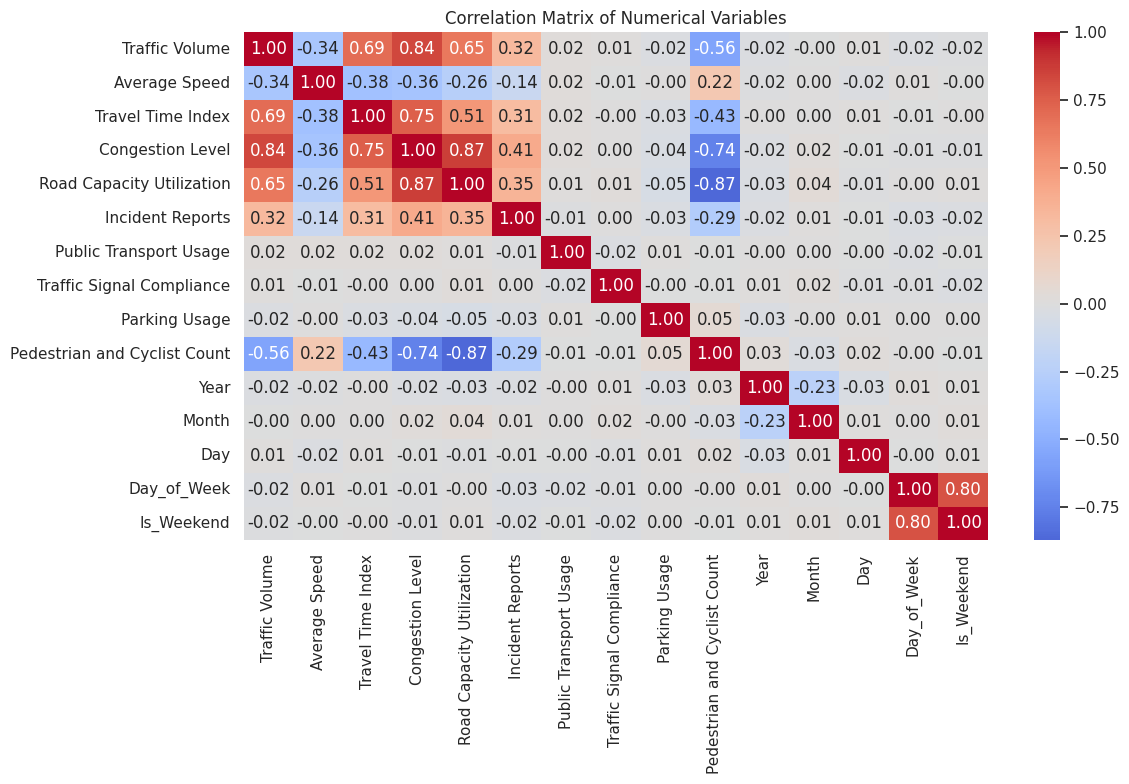

In [12]:
# ============================================================
# 12. NUMERICAL CORRELATION MATRIX
# ============================================================

numeric_model_columns = df_model.select_dtypes(
    include=np.number
).columns

corr_matrix = df_model[numeric_model_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 13. CORRELATION WITH TRAFFIC VOLUME
# ============================================================

target_correlations = (
    df_model[numeric_model_columns]
    .corr()[TARGET]
    .sort_values(ascending=False)
)

print("Correlation with Traffic Volume:")
display(target_correlations.to_frame("Correlation"))

Correlation with Traffic Volume:


,Correlation
Traffic Volume,1.000000
Congestion Level,0.835669
Travel Time Index,0.694949
Road Capacity Utilization,0.653462
Incident Reports,0.323355
Public Transport Usage,0.023638
Day,0.010385
Traffic Signal Compliance,0.006112
Month,-0.003429
Is_Weekend,-0.016234


,mean,median,std,count
Area Name,,,,
Koramangala,40505.744136,42926.0,14469.525964,469
M.G. Road,35567.961460,37401.0,11519.055836,493
Indiranagar,32008.519726,33601.0,11217.836764,583
Hebbal,27079.492308,28435.0,10203.223001,325
Jayanagar,25079.722078,25959.0,8505.072066,385
Whitefield,21404.852090,21814.0,7768.999444,311
Yeshwanthpur,18649.247934,18352.5,6959.025253,242
Electronic City,16145.052083,15587.0,6251.393846,192


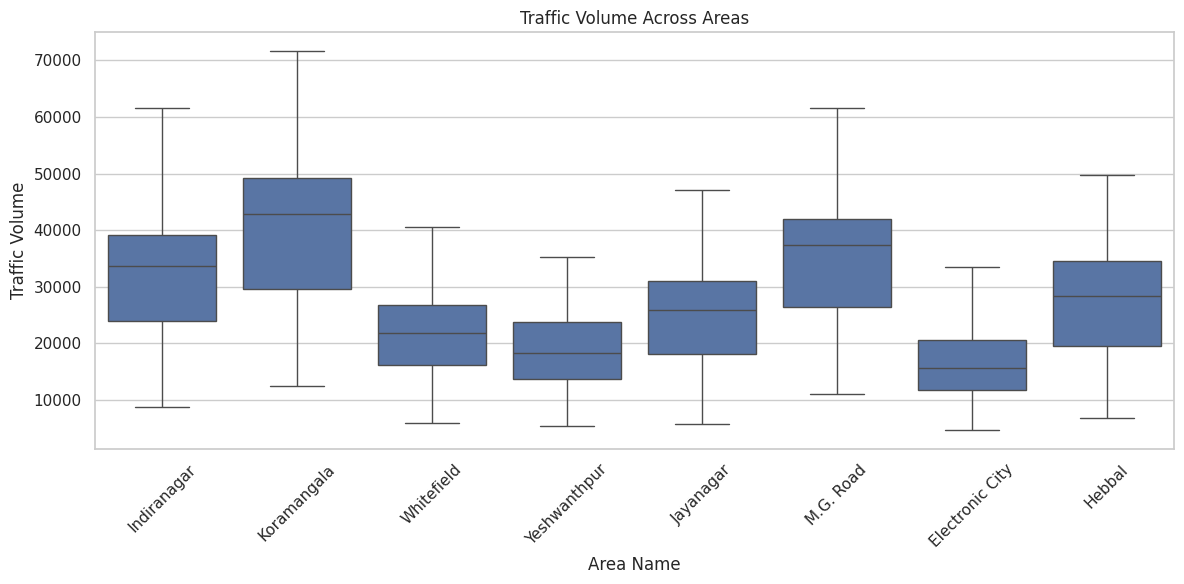

In [14]:
# ============================================================
# 14. TRAFFIC VOLUME BY AREA
# ============================================================

area_summary = (
    df_model
    .groupby("Area Name")[TARGET]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", ascending=False)
)

display(area_summary)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_model,
    x="Area Name",
    y=TARGET
)

plt.xticks(rotation=45)
plt.title("Traffic Volume Across Areas")
plt.tight_layout()
plt.show()

,mean,median,std,count
Weather Conditions,,,,
Windy,31193.339744,29629.5,14285.377963,156
Rain,29989.552347,28436.0,13554.240136,277
Clear,29355.274629,27676.0,12766.797554,1817
Fog,28557.800000,27146.0,12856.535191,335
Overcast,28532.306024,26843.0,13211.233593,415


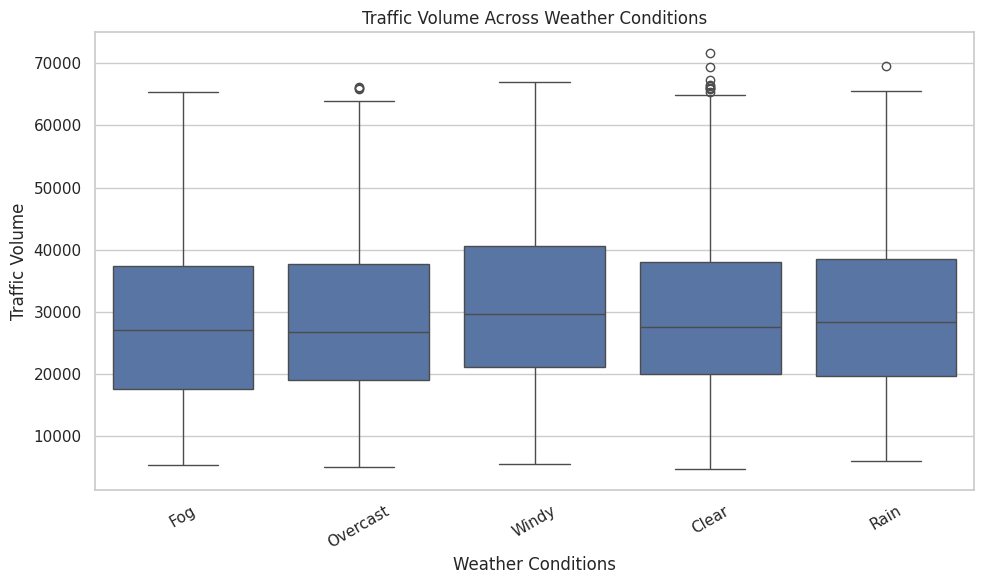

In [15]:
# ============================================================
# 15. TRAFFIC VOLUME BY WEATHER
# ============================================================

weather_summary = (
    df_model
    .groupby("Weather Conditions")[TARGET]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", ascending=False)
)

display(weather_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_model,
    x="Weather Conditions",
    y=TARGET
)

plt.title("Traffic Volume Across Weather Conditions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

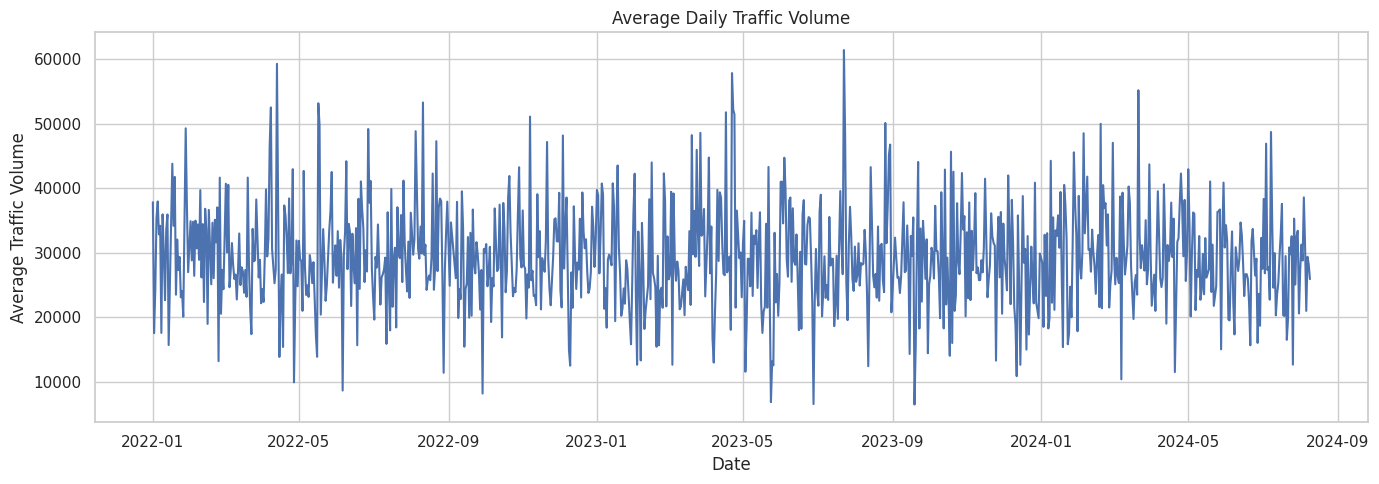

In [16]:
# ============================================================
# 16. TRAFFIC VOLUME OVER TIME
# ============================================================

daily_traffic = (
    df_model
    .groupby("Date")[TARGET]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_traffic,
    x="Date",
    y=TARGET
)

plt.title("Average Daily Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Average Traffic Volume")

plt.tight_layout()
plt.show()

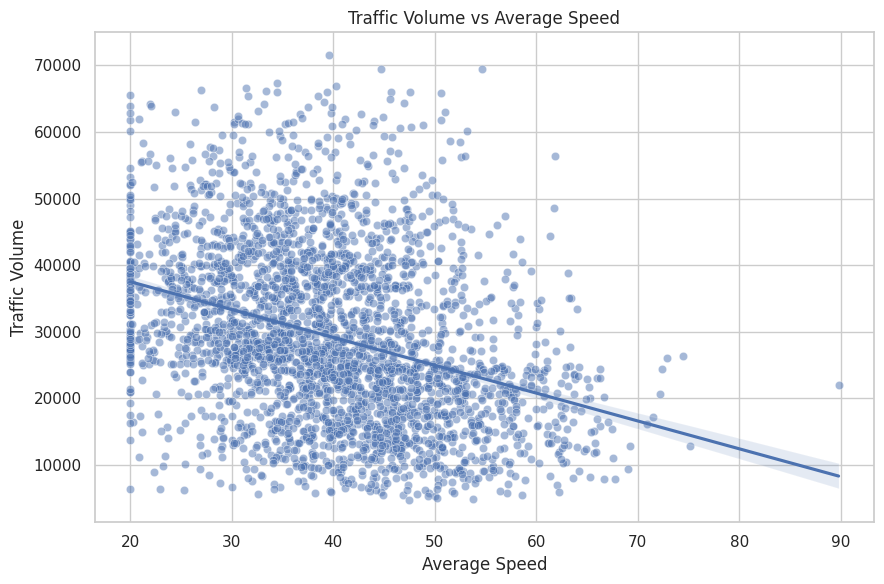

In [17]:
# ============================================================
# 17. TRAFFIC VOLUME VS AVERAGE SPEED
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_model,
    x="Average Speed",
    y=TARGET,
    alpha=0.5
)

sns.regplot(
    data=df_model,
    x="Average Speed",
    y=TARGET,
    scatter=False
)

plt.title("Traffic Volume vs Average Speed")
plt.tight_layout()
plt.show()

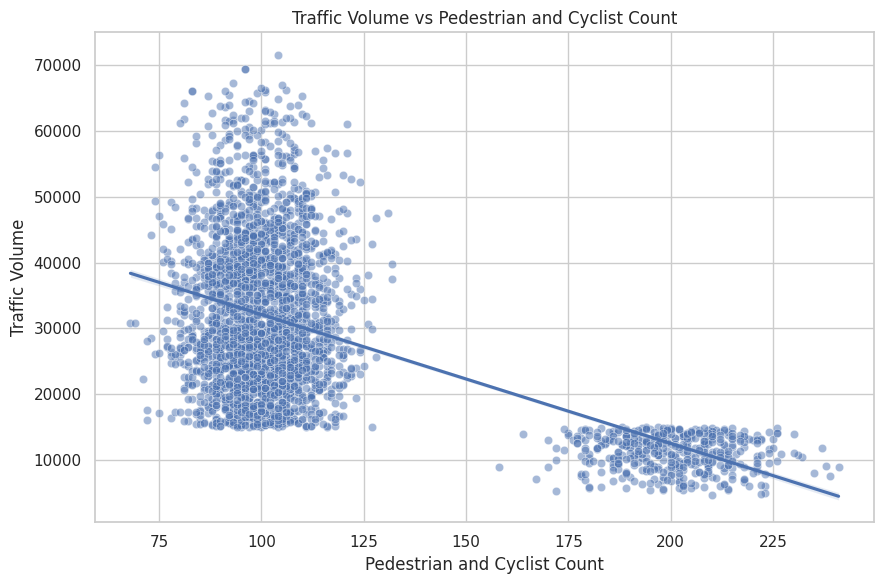

In [18]:
# ============================================================
# 18. TRAFFIC VOLUME VS PEDESTRIAN/CYCLIST COUNT
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_model,
    x="Pedestrian and Cyclist Count",
    y=TARGET,
    alpha=0.5
)

sns.regplot(
    data=df_model,
    x="Pedestrian and Cyclist Count",
    y=TARGET,
    scatter=False
)

plt.title(
    "Traffic Volume vs Pedestrian and Cyclist Count"
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 19. PEARSON CORRELATION TESTS
# ============================================================

correlation_results = []

numeric_predictors = [
    col for col in numeric_model_columns
    if col != TARGET
]

for col in numeric_predictors:

    temp = df_model[[col, TARGET]].dropna()

    r, p = pearsonr(
        temp[col],
        temp[TARGET]
    )

    correlation_results.append({
        "Variable": col,
        "Pearson r": r,
        "p-value": p
    })

correlation_results_df = pd.DataFrame(
    correlation_results
).sort_values(
    "Pearson r",
    key=abs,
    ascending=False
)

display(correlation_results_df)

,Variable,Pearson r,p-value
2,Congestion Level,0.835669,0.000000e+00
1,Travel Time Index,0.694949,0.000000e+00
3,Road Capacity Utilization,0.653462,0.000000e+00
8,Pedestrian and Cyclist Count,-0.559692,5.904094e-247
0,Average Speed,-0.337931,4.918058e-81
4,Incident Reports,0.323355,5.706713e-74
12,Day_of_Week,-0.024011,1.885820e-01
5,Public Transport Usage,0.023638,1.955401e-01
9,Year,-0.020599,2.593548e-01
7,Parking Usage,-0.018841,3.022454e-01


In [20]:
# ============================================================
# 20. ONE-WAY ANOVA: WEATHER VS TRAFFIC VOLUME
# ============================================================

weather_groups = [
    group[TARGET].values
    for _, group in df_model.groupby(
        "Weather Conditions"
    )
]

anova_stat, anova_p = f_oneway(*weather_groups)

print("ANOVA F-statistic:", anova_stat)
print("ANOVA p-value:", anova_p)

if anova_p < 0.05:
    print(
        "Result: Traffic volume differs significantly "
        "across at least some weather groups."
    )
else:
    print(
        "Result: No statistically significant difference "
        "was detected across weather groups."
    )

ANOVA F-statistic: 1.6660860000537803
ANOVA p-value: 0.1550340767098196
Result: No statistically significant difference was detected across weather groups.


In [21]:
# ============================================================
# 21. PREPARE FEATURES AND TARGET
# ============================================================

X = df_model.drop(
    columns=[TARGET, "Date"]
)

y = df_model[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumerical predictors:")
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print(numeric_features)

print("\nCategorical predictors:")
categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print(categorical_features)

X shape: (3000, 18)
y shape: (3000,)

Numerical predictors:
['Average Speed', 'Travel Time Index', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage', 'Pedestrian and Cyclist Count', 'Year', 'Month', 'Day', 'Day_of_Week', 'Is_Weekend']

Categorical predictors:
['Area Name', 'Road/Intersection Name', 'Weather Conditions', 'Roadwork and Construction Activity']


In [22]:
# ============================================================
# 22. PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [23]:
# ============================================================
# 23. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target mean:", y_train.mean())
print("Testing target mean:", y_test.mean())

Training samples: 2400
Testing samples: 600

Training target mean: 29356.7
Testing target mean: 29105.818333333333


In [24]:
# ============================================================
# 24. LINEAR REGRESSION
# ============================================================

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [25]:
# ============================================================
# 25. DECISION TREE REGRESSION
# ============================================================

tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=10,
                min_samples_leaf=5,
                random_state=RANDOM_STATE
            )
        )
    ]
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(
    X_test
)

print("Decision Tree Regression trained successfully.")

Decision Tree Regression trained successfully.


In [26]:
# ============================================================
# 26. EVALUATION FUNCTION
# ============================================================

def evaluate_regression_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }


results = []

results.append(
    evaluate_regression_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_regression_model(
        "Decision Tree Regression",
        y_test,
        tree_predictions
    )
)

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,4610.711189,3.889546e+07,6236.622807,0.751620
1,Decision Tree Regression,3679.990420,4.023937e+07,6343.450682,0.743038


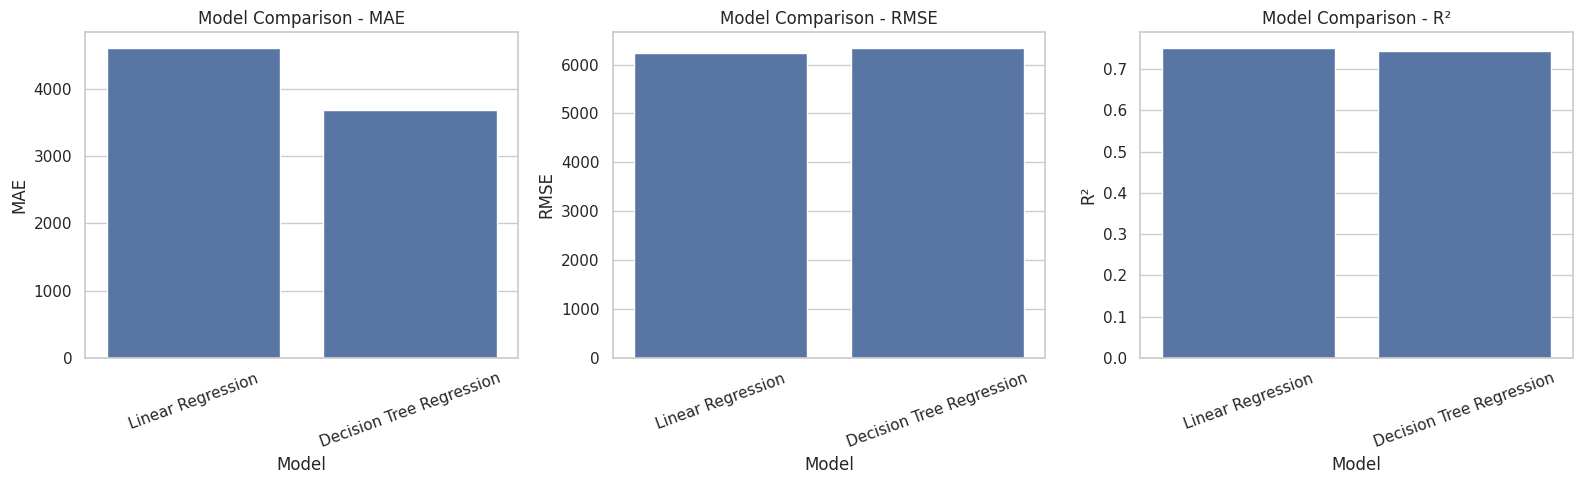

In [27]:
# ============================================================
# 27. MODEL COMPARISON
# ============================================================

metrics_to_plot = [
    "MAE",
    "RMSE",
    "R²"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

for ax, metric in zip(
    axes,
    metrics_to_plot
):

    sns.barplot(
        data=results_df,
        x="Model",
        y=metric,
        ax=ax
    )

    ax.set_title(
        f"Model Comparison - {metric}"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

plt.tight_layout()
plt.show()

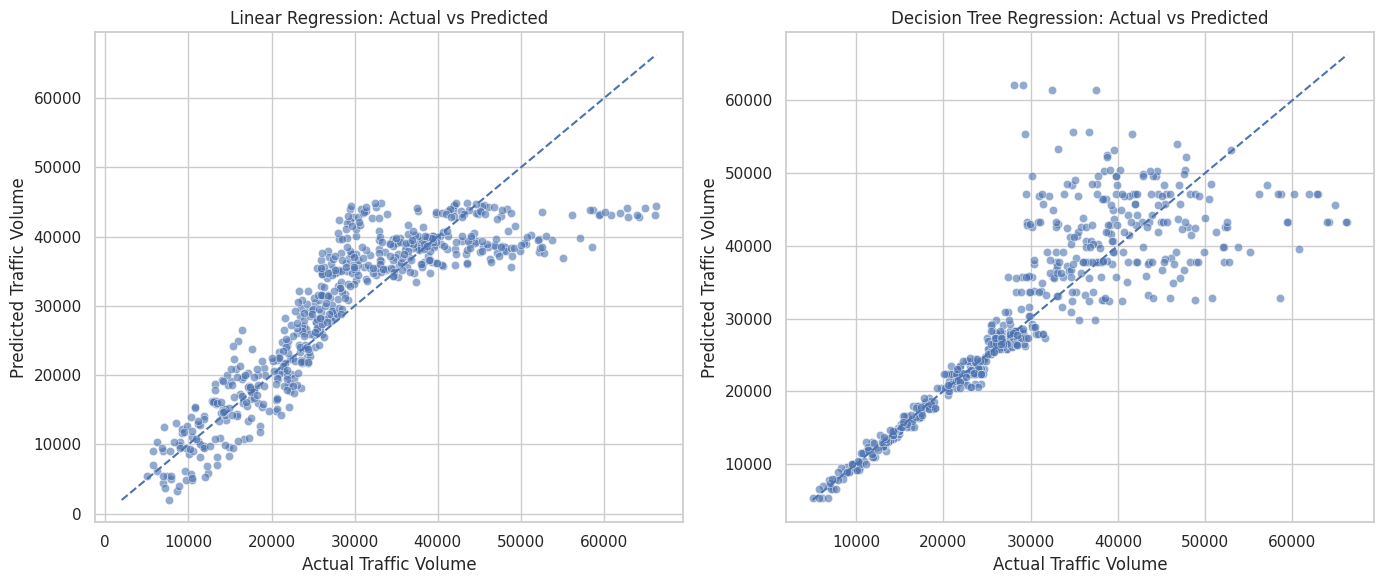

In [28]:
# ============================================================
# 28. ACTUAL VS PREDICTED
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

predictions_dict = {
    "Linear Regression": linear_predictions,
    "Decision Tree Regression": tree_predictions
}

for ax, (name, predictions) in zip(
    axes,
    predictions_dict.items()
):

    sns.scatterplot(
        x=y_test,
        y=predictions,
        alpha=0.6,
        ax=ax
    )

    min_value = min(
        y_test.min(),
        predictions.min()
    )

    max_value = max(
        y_test.max(),
        predictions.max()
    )

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    ax.set_title(
        f"{name}: Actual vs Predicted"
    )

    ax.set_xlabel("Actual Traffic Volume")
    ax.set_ylabel("Predicted Traffic Volume")

plt.tight_layout()
plt.show()

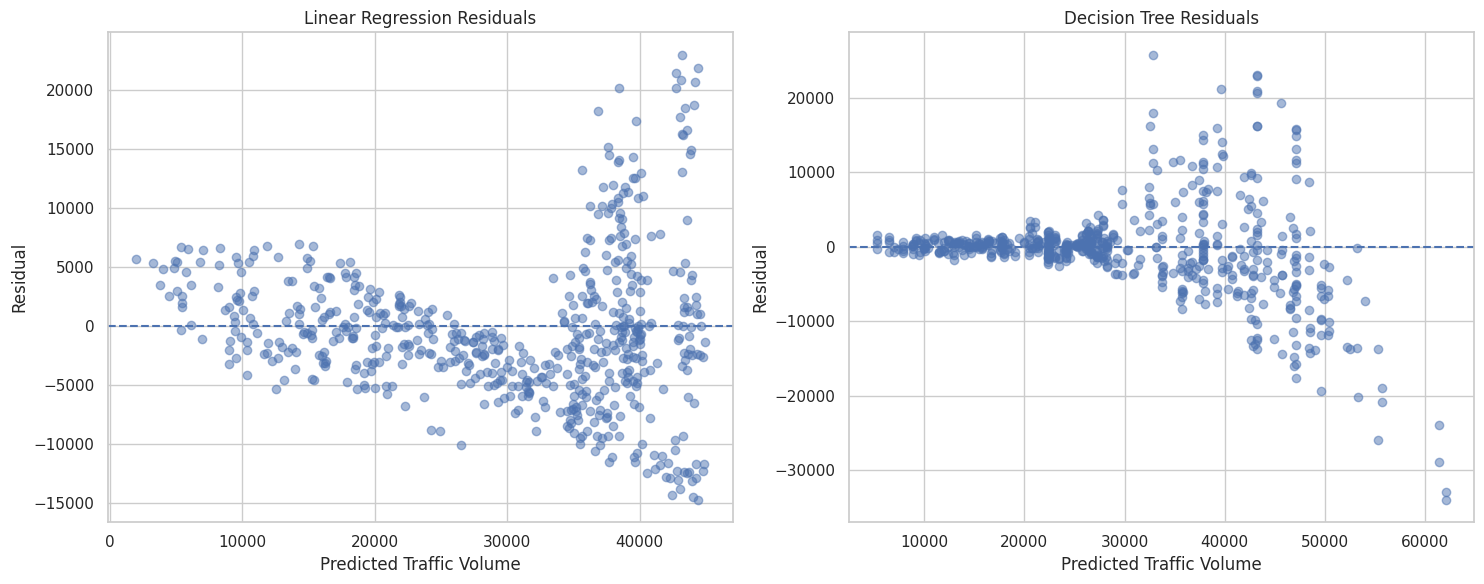

In [29]:
# ============================================================
# 29. RESIDUAL ANALYSIS
# ============================================================

linear_residuals = (
    y_test - linear_predictions
)

tree_residuals = (
    y_test - tree_predictions
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

axes[0].scatter(
    linear_predictions,
    linear_residuals,
    alpha=0.5
)

axes[0].axhline(
    0,
    linestyle="--"
)

axes[0].set_title(
    "Linear Regression Residuals"
)

axes[0].set_xlabel(
    "Predicted Traffic Volume"
)

axes[0].set_ylabel(
    "Residual"
)


axes[1].scatter(
    tree_predictions,
    tree_residuals,
    alpha=0.5
)

axes[1].axhline(
    0,
    linestyle="--"
)

axes[1].set_title(
    "Decision Tree Residuals"
)

axes[1].set_xlabel(
    "Predicted Traffic Volume"
)

axes[1].set_ylabel(
    "Residual"
)

plt.tight_layout()
plt.show()

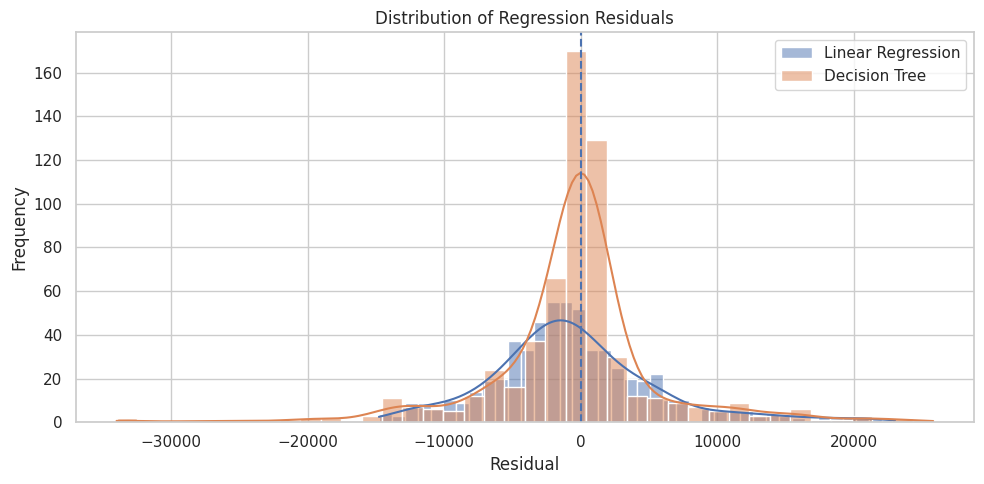

In [30]:
# ============================================================
# 30. RESIDUAL DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    linear_residuals,
    kde=True,
    bins=40,
    label="Linear Regression",
    alpha=0.5
)

sns.histplot(
    tree_residuals,
    kde=True,
    bins=40,
    label="Decision Tree",
    alpha=0.5
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 31. DECISION TREE FEATURE IMPORTANCE
# ============================================================

# Get fitted preprocessing pipeline
fitted_preprocessor = tree_model.named_steps[
    "preprocessor"
]

tree_estimator = tree_model.named_steps[
    "model"
]

# Get transformed feature names
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

importance_values = (
    tree_estimator.feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance_df.head(15)
)

,Feature,Importance
2,num__Congestion Level,0.738229
3,num__Road Capacity Utilization,0.131858
18,cat__Area Name_Koramangala,0.033026
1,num__Travel Time Index,0.013813
19,cat__Area Name_M.G. Road,0.012534
6,num__Traffic Signal Compliance,0.009808
0,num__Average Speed,0.009419
16,cat__Area Name_Indiranagar,0.008244
5,num__Public Transport Usage,0.006286
11,num__Day,0.006252


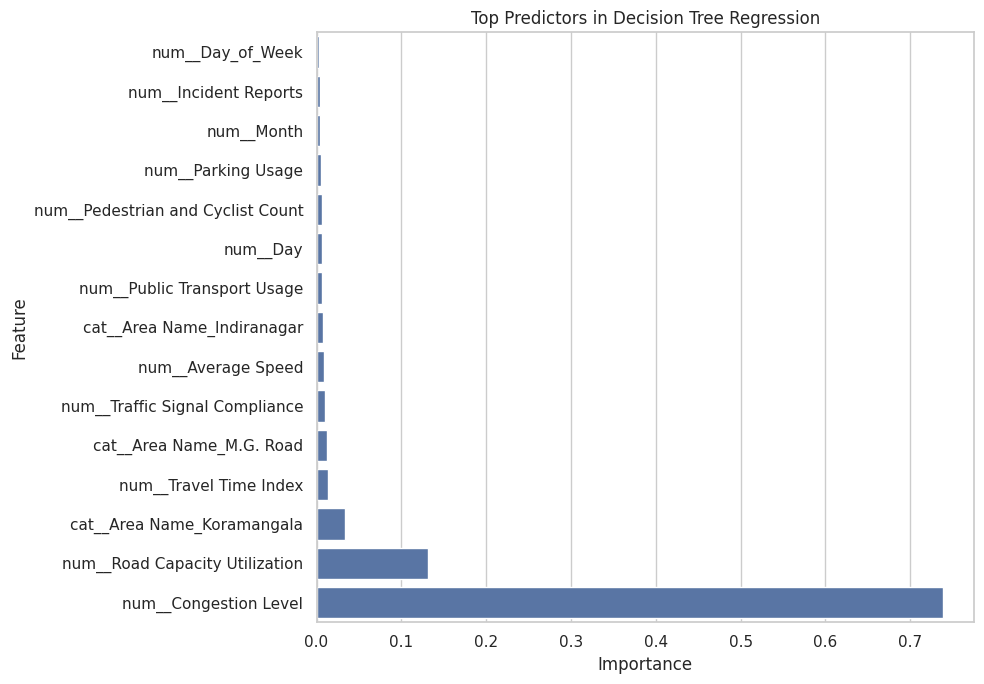

In [32]:
# ============================================================
# 32. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Predictors in Decision Tree Regression"
)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 33. LINEAR REGRESSION COEFFICIENTS
# ============================================================

linear_preprocessor = linear_model.named_steps[
    "preprocessor"
]

linear_estimator = linear_model.named_steps[
    "model"
]

linear_feature_names = (
    linear_preprocessor
    .get_feature_names_out()
)

coefficients = linear_estimator.coef_

coefficient_df = pd.DataFrame({
    "Feature": linear_feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

display(
    coefficient_df.head(20)
)

,Feature,Coefficient,Absolute Coefficient
2,num__Congestion Level,11118.364609,11118.364609
18,cat__Area Name_Koramangala,4112.214050,4112.214050
3,num__Road Capacity Utilization,-2504.544089,2504.544089
33,cat__Road/Intersection Name_Sony World Junction,2296.034536,2296.034536
31,cat__Road/Intersection Name_Sarjapur Road,1816.179514,1816.179514
17,cat__Area Name_Jayanagar,-1637.527052,1637.527052
19,cat__Area Name_M.G. Road,1489.040333,1489.040333
20,cat__Area Name_Whitefield,-1438.287904,1438.287904
15,cat__Area Name_Hebbal,-1142.415630,1142.415630
42,cat__Weather Conditions_Windy,1122.114034,1122.114034


In [34]:
# ============================================================
# 34. FINAL RESULTS TABLE
# ============================================================

results_df = results_df.copy()

results_df = results_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4
})

print("FINAL MODEL COMPARISON")
display(results_df)

# Save results if required
results_df.to_csv(
    "regression_model_results.csv",
    index=False
)

print("Results saved as regression_model_results.csv")

FINAL MODEL COMPARISON


,Model,MAE,MSE,RMSE,R²
0,Linear Regression,4610.71,38895464.04,6236.62,0.7516
1,Decision Tree Regression,3679.99,40239366.55,6343.45,0.7430


Results saved as regression_model_results.csv


In [35]:
# ============================================================
# 35. AUTOMATIC MODEL COMPARISON SUMMARY
# ============================================================

best_mae_model = results_df.loc[
    results_df["MAE"].idxmin(),
    "Model"
]

best_rmse_model = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

best_r2_model = results_df.loc[
    results_df["R²"].idxmax(),
    "Model"
]

print("Model with lowest MAE:", best_mae_model)
print("Model with lowest RMSE:", best_rmse_model)
print("Model with highest R²:", best_r2_model)

Model with lowest MAE: Decision Tree Regression
Model with lowest RMSE: Linear Regression
Model with highest R²: Linear Regression


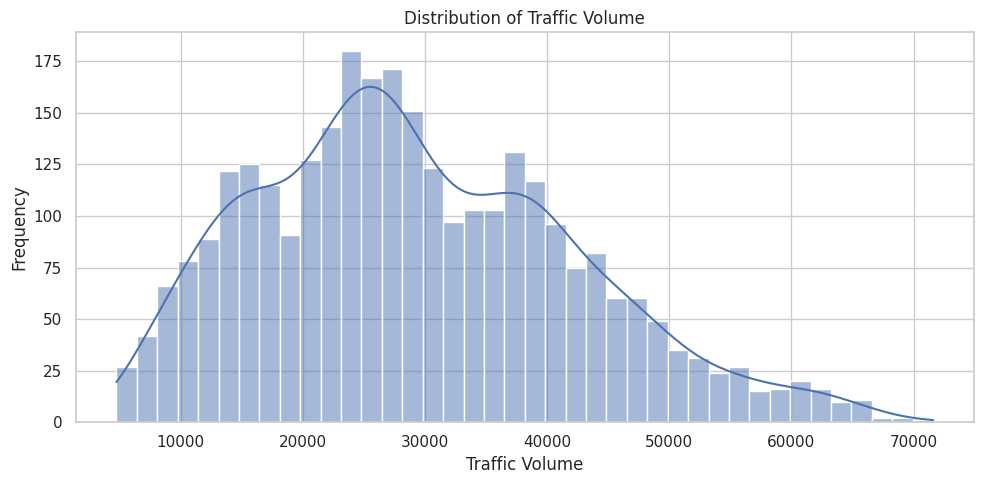

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_model[TARGET],
    kde=True,
    bins=40
)

plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "figure_1_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()